# 06 — Add-on-rise ladder vs stop-loss

Two opposite ways to handle the runner tail, on the same 766 pumps, same max
budget (1.0), same time-exit (+240m unless a rule fires earlier):

- **stop-loss**: short full at trigger, bail if price rises S% against avg entry.
- **add-on-rise ladder** (your idea): start small, add as price rises (sell higher),
  capped at 1.0; optional take-profit when price falls back below avg entry.

PnL is return on the **max** budget (idle/unfilled capital earns 0) so the two
are directly comparable.

In [1]:
import sys; sys.path.insert(0, '.')
from _lab import *

paths = np.load('_out/pump_paths.npy')
PRE = 60
EXIT = 240
# price relative to trigger, sliced so column 0 = trigger bar
P = (1.0 + paths)[:, PRE:PRE + EXIT + 1]
print('events:', P.shape[0], '| steps to exit:', P.shape[1] - 1)

events: 766 | steps to exit: 240


In [2]:
def simulate(price, init=1.0, add_step=None, n_add=0, add_size=0.0,
             stop=None, tp=None):
    """Short sim along one path (price[0]=trigger). Returns PnL on max budget=1.0.

    add_step : add a tranche each time price rises this fraction above last add level
    n_add    : how many add tranches are allowed
    add_size : size of each add tranche (budget units)
    stop     : exit if price >= avg_entry*(1+stop)   (adverse)
    tp       : exit if price <= avg_entry*(1-tp)      (favorable, 'started falling')
    """
    budget = init + n_add * add_size          # = 1.0 by construction
    size = init
    notional = init * price[0]                # sum(size_i * entry_i)
    last_add = price[0]
    adds_left = n_add
    exit_price = price[-1]
    for t in range(1, len(price)):
        p = price[t]
        while adds_left > 0 and p >= last_add * (1 + add_step):
            last_add *= (1 + add_step)
            size += add_size
            notional += add_size * last_add
            adds_left -= 1
        avg = notional / size
        if stop is not None and p >= avg * (1 + stop):
            exit_price = p; break
        if tp is not None and p <= avg * (1 - tp):
            exit_price = p; break
    # short PnL on budget: each filled unit earns (1 - exit/entry); unfilled earns 0
    return (size / budget) * (1.0 - exit_price / (notional / size))

def run(**kw):
    return np.array([simulate(P[i], **kw) for i in range(P.shape[0])])

def stats(p):
    return (p.mean()*100, np.median(p)*100, (p>0).mean()*100,
            p.std()*100, np.quantile(p, .1)*100, p.mean()/p.std())

HDR = f"{'strategy':<26}{'mean':>8}{'median':>8}{'win%':>7}{'std':>8}{'q10':>8}{'m/std':>8}"
def show_row(name, p):
    m, md, w, sd, q, sh = stats(p)
    print(f"{name:<26}{m:>+7.2f}%{md:>+7.2f}%{w:>6.1f}%{sd:>7.2f}%{q:>+7.2f}%{sh:>8.3f}")

base = run()
print(HDR); show_row('baseline full@trigger', base)

strategy                      mean  median   win%     std     q10   m/std
baseline full@trigger       +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248


## Stop-loss sweep

In [3]:
print(HDR); show_row('baseline (no stop)', base)
stop_res = {}
for S in [0.03, 0.05, 0.08, 0.12, 0.20]:
    p = run(stop=S)
    stop_res[S] = p
    show_row(f'stop {int(S*100)}%', p)

strategy                      mean  median   win%     std     q10   m/std
baseline (no stop)          +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248
stop 3%                     +1.39%  +1.11%  56.5%   4.86%  -3.76%   0.286
stop 5%                     +1.37%  +1.42%  60.4%   5.22%  -5.33%   0.263
stop 8%                     +1.45%  +1.77%  63.6%   5.66%  -8.06%   0.257
stop 12%                    +1.43%  +1.85%  64.4%   5.87%  -6.72%   0.244
stop 20%                    +1.41%  +1.85%  64.4%   6.02%  -6.57%   0.234


## Add-on-rise ladder (your idea)
Start at 0.25, add 0.25 each time price rises another `add_step`, max 1.0 (4 tranches).

In [4]:
print(HDR); show_row('baseline', base)
lad_res = {}
for g in [0.01, 0.02, 0.03, 0.05]:
    p = run(init=0.25, add_step=g, n_add=3, add_size=0.25)
    lad_res[g] = p
    show_row(f'ladder +{int(g*100)}%/step', p)

strategy                      mean  median   win%     std     q10   m/std
baseline                    +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248
ladder +1%/step             +0.34%  +0.95%  71.8%   4.02%  -4.84%   0.085
ladder +2%/step             +0.36%  +0.78%  71.8%   3.31%  -3.28%   0.109
ladder +3%/step             +0.35%  +0.62%  70.5%   2.71%  -2.34%   0.129


ladder +5%/step             +0.40%  +0.56%  67.4%   2.15%  -1.75%   0.185


## Ladder + take-profit (the full idea: add while rising, close when it falls back)

In [5]:
print(HDR); show_row('baseline', base)
ladtp_res = {}
for g in [0.02, 0.03]:
    for tp in [0.015, 0.03, 0.05]:
        p = run(init=0.25, add_step=g, n_add=3, add_size=0.25, tp=tp)
        ladtp_res[(g, tp)] = p
        show_row(f'ladder +{int(g*100)}% / tp {tp*100:.1f}%', p)

strategy                      mean  median   win%     std     q10   m/std
baseline                    +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248
ladder +2% / tp 1.5%        -0.17%  +0.44%  83.2%   2.21%  -2.01%  -0.076
ladder +2% / tp 3.0%        +0.02%  +0.79%  76.9%   2.55%  -2.58%   0.007


ladder +2% / tp 5.0%        +0.25%  +1.25%  73.1%   2.88%  -2.86%   0.086
ladder +3% / tp 1.5%        -0.07%  +0.43%  82.1%   1.83%  -1.67%  -0.038
ladder +3% / tp 3.0%        +0.08%  +0.78%  75.7%   2.11%  -1.92%   0.038
ladder +3% / tp 5.0%        +0.25%  +0.97%  71.8%   2.35%  -2.09%   0.106


## Head-to-head: pick the best of each by mean/std, compare tails

strategy                      mean  median   win%     std     q10   m/std
baseline full@trigger       +1.47%  +1.87%  64.5%   5.92%  -6.42%   0.248
stop 3%                     +1.39%  +1.11%  56.5%   4.86%  -3.76%   0.286
ladder +5%                  +0.40%  +0.56%  67.4%   2.15%  -1.75%   0.185
ladder+tp (0.03, 0.05)      +0.25%  +0.97%  71.8%   2.35%  -2.09%   0.106


[saved] notebooks\_out\06_ladder_vs_stop.png


WindowsPath('C:/projects/researchlab/notebooks/_out/06_ladder_vs_stop.png')

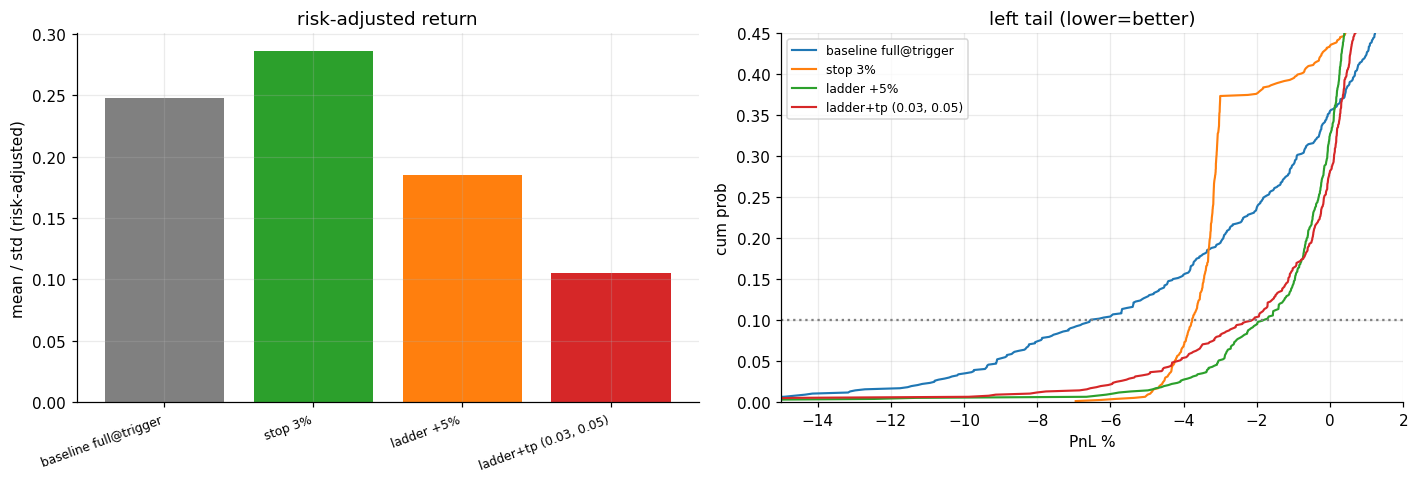

In [6]:
best_stop = max(stop_res.items(), key=lambda kv: stats(kv[1])[5])
best_lad  = max(lad_res.items(),  key=lambda kv: stats(kv[1])[5])
best_ltp  = max(ladtp_res.items(), key=lambda kv: stats(kv[1])[5])
cmp = {
    'baseline full@trigger': base,
    f'stop {int(best_stop[0]*100)}%': best_stop[1],
    f'ladder +{int(best_lad[0]*100)}%': best_lad[1],
    f'ladder+tp {best_ltp[0]}': best_ltp[1],
}
print(HDR)
for n, p in cmp.items():
    show_row(n, p)

fig, (axb, axc) = plt.subplots(1, 2, figsize=(13, 4.5))
names = list(cmp); shr = [stats(cmp[n])[5] for n in names]
axb.bar(range(len(names)), shr, color=['gray','tab:green','tab:orange','tab:red'])
axb.set_xticks(range(len(names))); axb.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
axb.set_ylabel('mean / std (risk-adjusted)'); axb.set_title('risk-adjusted return')
for n, p in cmp.items():
    s = np.sort(p*100); cdf = np.arange(1, len(s)+1)/len(s)
    axc.plot(s, cdf, lw=1.4, label=n)
axc.set_xlim(-15, 2); axc.set_ylim(0, 0.45); axc.axhline(0.1, color='gray', ls=':')
axc.set_xlabel('PnL %'); axc.set_ylabel('cum prob'); axc.set_title('left tail (lower=better)')
axc.legend(fontsize=8)
show('06_ladder_vs_stop')